# Bliskost-sličnost i različitost

- **Sličnost**
 - numerička mera koliko su dva objekta slična
 - što dva objekta više liče jedan na drugi sličnost im je veća
 - često se izražava vrednostima u intervalu [0, 1]
 - kada koristimo?
    - za detekciju grešaka u podacima (nastalih npr. greškom u kucanju)
    - za uočavanje grupa u podacima, tj. podataka koji su jako slični (klasteri)

- **Različitost**
 - numerička mera koliko su dva objekta različita
 - što dva objekta više liče jedan na drugi različitost im je manja
 - najmanja vrednost mere različitosti je često 0, dok gornja granica može biti razna
 - kao sinonim koristi se i termin rastojanje
 - kada koristimo?<br>
    - za pronalaženje outlajera i izuzetaka
    - za određivanje granica klastera

- **Blizina** (eng. *proximity*) označava ili sličnost ili različitost

<img src="assets/mere.png" width="750">

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

### Mera sličnosti za nominalne (imenske) atribute

$s(p, q) = \left\{ 
  \begin{array}{ c l }
    1 & \quad \textrm{ako } p = q \\
    0                 & \quad \textrm{inače}
  \end{array}
\right.$

In [2]:
def similarity_nominal(p, q): 
    return int(p==q)

*Primer:*

In [3]:
similarity_nominal("Petar", "Jovan")

0

In [4]:
similarity_nominal("Petar", "Petar") 

1

### Mera različitosti za nominalne (imenske) atribute

$d(p, q) = \left\{ 
  \begin{array}{ c l }
    0 & \quad \textrm{ako } p = q \\
    1                 & \quad \textrm{inače}
  \end{array}
\right.$

In [5]:
def dissimilarity_nominal(p, q):
    return 1 - similarity_nominal(p, q)

*Primer:*

In [6]:
dissimilarity_nominal("Petar", "Jovan") 

1

In [7]:
dissimilarity_nominal("Petar", "Petar") 

0

### Mera različitosti za ordinalne (redne) atribute

$
d(p, q) = \frac{|p'-q'|}{n-1}
$

Vrednosti ordinalnog atributa se preslikavaju u cele brojeve od $0$ do $n-1$, gde je $n$ broj mogućih vrednosti atributa, u skladu sa postojećim uređenjem nad originalnim vrednostima. Dakle $p'$ i $q'$ su numeričke vrednosti koje odgovaraju $p$ i $q$.

<u>PRIMER:</u> veličine odeće <br/>
S  <  M < L < XL < XXL <br/>
S &rarr; 0 <br/> 
M &rarr; 1 <br/>
L &rarr; 2 <br/>
XL &rarr; 3 <br/> 

In [8]:
def dissimilarity_ordinal(p, q, values):
    n = len(values)
    map_values = {v : i for i, v in enumerate(values)}
    return abs(map_values[p] - map_values[q]) / (n-1)

*Primer:*

In [9]:
dissimilarity_ordinal("M", "XL", ["S", "M", "L", "XL"])  

0.6666666666666666

In [10]:
dissimilarity_ordinal("S", "XL", ["S", "M", "L", "XL"])  

1.0

### Mera sličnosti za ordinalne (redne) atribute

$
s(p, q) = 1 - d(p, q)
$

In [11]:
def similarity_ordinal(p, q, values):
    return 1 - dissimilarity_ordinal(p, q, values)

*Primer:*

In [12]:
similarity_ordinal("M", "XL", ["S", "M", "L", "XL"]) 

0.33333333333333337

In [13]:
similarity_ordinal("S", "XL", ["S", "M", "L", "XL"])  

0.0

### Mere različitosti za kvantitativne atribute

$d(p, q) = |p-q| $

In [14]:
def dissimilarity_quantity(p, q):
    return abs(p - q)

*Primer:*

In [15]:
import datetime
dissimilarity_quantity(datetime.date(2020, 3, 25), datetime.date(2020, 7, 24))

datetime.timedelta(days=121)

### Mere sličnosti za kvantitativne atribute - opcija 1

$s(p, q) = -d(p, q)$

In [16]:
def similarity_quantity_1(p, q):
    return -dissimilarity_quantity(p, q)

*Primer:*

In [17]:
similarity_quantity_1(datetime.date(2020, 3, 25), datetime.date(2020, 7, 24))

datetime.timedelta(days=-121)

### Mere sličnosti za kvantitativne atribute - opcija 2

$s(p, q) = \frac{1}{1+d}$

In [18]:
def similarity_quantity_2(p, q):
    return 1 / (1 + dissimilarity_quantity(p, q).days)

*Primer:*

In [19]:
similarity_quantity_2(datetime.date(2020, 3, 25), datetime.date(2020, 7, 24)) 

0.00819672131147541

## Različitosti između objekata podataka

Objekte predstavljamo kao vektore u *n*-dimenzionom prostoru:
$X = (x_1, x_2, . . . , x_n)$, $Y = (y_1, y_2, . . . , y_n)$
gde je $n$ broj atributa (dimenzija). Možemo govoriti o razlici na nivou pojedinačnih atributa, a mera različitosti kombinuje ove pojedinačne razlike u jednu ukupnu vrednost.

- Hamingovo rastojanje
- Rastojanje Minkovskog

### Hamingovo rastojanje
- broj različitih vrednosti atributa

$hamming(x, y) = \sum_{i=1}^{n} I (x_i \neq y_i)$

gde je $I$ indikatorska funkcija, tj. 
$I (x_i \neq y_i) = \begin{cases} 
  1 & x_i \neq y_i \\
  0 & x_i = y_i
\end{cases}$

In [20]:
def hamming_distance(x, y):
    n = len(x)       
    
    dist = 0
    for i in range(n):
        if x[i] != y[i]:
            dist += 1
            
    return dist

*Primer:* poređenje (nukleotidnih) sekvenci

In [21]:
x = "AAGTAGCT"
y = "ACGTGGCG"

hamming_distance(x, y)

3

### Rastojanje Minkovskog

- rastojanje indukovano normom

$ mink(x, y) = (\sum_{i=1}^{n}|x_i-y_i|^r)^\frac{1}{r}$

 - $r$ parametar
 - $n$ broj dimenzija (atributa)
 - $x_i$ i $y_i$ su vrednosti $i$-tog atributa objekata $x$ i $y$
 
Specijalni slučajevi rastojanja Minkovskog:

- **r = 1** Menhetn rastojanje ($L_1$ norma)
    - u slučaju binarnih podataka - Hamingovo rastojanje
- **r = 2** Euklidsko rastojanje ($L_2$ norma)
-  **r → ∞**  supremum rastojanje ($L_\infty$ ili $L_{max}$ norma) 
    - predstavlja maksimum razlike između odgovarajucih komponenti vektora

In [22]:
def minkowski(x, y, r):
    if r <= 0:
        raise ValueError("r is not positive!")
    return (sum([abs(x[v] - y[v])**r for v in x.index])**(1/r))  

#### Zadatak 1:
Posmatramo naredni skup tačaka:

|point |x  | y|
--- | --- | ---|
|**p1**|0|2|
|**p2**|2|0|
|**p3**|3|1|
|**p4**|5|1|

Izračunati $L_1$, $L_2$, $L_{\infty}$ normu:

In [23]:
points = pd.DataFrame([[0,2], [2, 0], [3, 1], [5, 1]], index=["p1", "p2", "p3", "p4"], columns=["x", "y"])
points

,x,y
p1,0,2
p2,2,0
p3,3,1
p4,5,1


Text(0.5, 1.0, 'Points')

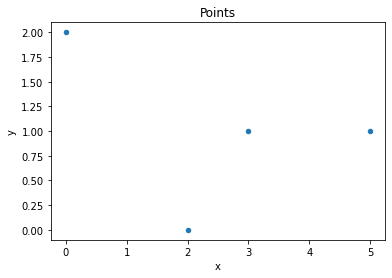

In [24]:
points.plot.scatter("x", "y")
plt.title("Points")

a) Izračunati L1 normu: 

Očekivan izlaz:

|$L_1$|p1| p2|p3|p4|
--- | --- | ---| ---|---|
|**p1**|0|4|4|6|
|**p2**|4|0|2|4|
|**p3**|4|2|0|2|
|**p4**|6|4|2|0|

In [25]:
def L1(points):
    L1 = pd.DataFrame(0, index=points.index, columns=points.index)
    for p1 in points.index:
        for p2 in points.index:
            L1[p1][p2] = minkowski(points.loc[p1], points.loc[p2], 1)
    return L1

L1(points)

,p1,p2,p3,p4
p1,0,4,4,6
p2,4,0,2,4
p3,4,2,0,2
p4,6,4,2,0


a) Izračunati L2 normu: 

Očekivan izlaz:

|$L_2$|p1| p2|p3|p4|
--- | --- | ---| ---|---|
|**p1**|0.0|2.828|3.162|5.099|
|**p2**|2.828|0.0|1.414|3.162|
|**p3**|3.162|1.414|0.0|2.0|
|**p4**|5.099|3.162|2.0|0.0|

In [26]:
def L2(points):
    L2 = pd.DataFrame(0, index=points.index, columns=points.index, dtype='float64')
    for p1 in points.index:
        for p2 in points.index:
            L2[p1][p2] = minkowski(points.loc[p1], points.loc[p2], 2)
    return L2

L2(points)

,p1,p2,p3,p4
p1,0.000000,2.828427,3.162278,5.099020
p2,2.828427,0.000000,1.414214,3.162278
p3,3.162278,1.414214,0.000000,2.000000
p4,5.099020,3.162278,2.000000,0.000000


a) Izračunati Lmax normu: 

Očekivan izlaz:

|$L_max$|p1| p2|p3|p4|
--- | --- | ---| ---|---|
|**p1**|0|2|3|5|
|**p2**|2|0|1|3|
|**p3**|3|1|0|2|
|**p4**|5|3|2|0|

In [27]:
def Lmax(points):
    Lmax = pd.DataFrame(0, index=points.index, columns=points.index)
    for p1 in points.index:
        for p2 in points.index:
            Lmax[p1][p2] = max(abs(points.loc[p1] - points.loc[p2]))
    return Lmax

Lmax(points)

,p1,p2,p3,p4
p1,0,2,3,5
p2,2,0,1,3
p3,3,1,0,2
p4,5,3,2,0


<u>Domaći</u>: Optimizovati implementaciju funkcija L1, L2, Lmax na osnovu činjenice da su rezultujuće matrice simetrične.

## Sličnosti između objekata podataka

- Kosinusno rastojanje
- Korelacija

### Kosinusno rastojanje

- Koristi se kod asimetričnih podataka
- Najčešća mera sličnosti dokumenata

Ako su dokumenti predstavljeni vektorima $X = (x_1, x_2, . . . , x_d)$, $Y = (y_1, y_2, . . . , y_d)$:

$cos(X, Y) = \frac{X ⊙ Y}{||X||\cdot||Y||}$

⊙ - skalarni proizvod

$||X||$ - norma vektora $X$

In [28]:
def norm(x):
    return np.sqrt((x*x).sum())

In [29]:
def cosine_similarity(x, y):
    return (x*y).sum() / (norm(x)*norm(y))

In [30]:
X = pd.Series([1, 1, 0, 3, 0, 2, 4, 1, 0, 3])         #npr. frekvencije reci u recenicama X i Y
Y = pd.Series([0, 2, 2, 0, 0, 1, 1, 0, 0, 0])

cosine_similarity(X, Y) 

0.3950918386598358

### Korelacija
$corr(X, Y) = \frac{covariance(X, Y)}{σ(X) \cdot σ(Y)}$

Korelacija dva objekta koji imaju binarne ili neprekidne atribute
je mera <u>linearnog</u> odnosa između njihovih atributa

In [31]:
def correlation(X, Y):
    return (np.cov(X, Y) / (X.std()*Y.std()))[0][1]

In [32]:
X = pd.Series([1, 1, 0, 3, 0, 2, 4, 1, 0, 3])
Y = pd.Series([0, 2, 2, 0, 0, 1, 1, 0, 0, 0])

correlation(X, Y) 

-0.09190182776172595

Digresija:
- Ova mera se naziva još **Pirsonov koeficijent korelacije**. 
- Pirsonov koeficijent korelacije meri <u>jačinu</u> i <u>smer</u> linearne korelacije dve slucajne promenljive. 
- Vrednosti Pirsonovog koeficijent korelacije su iz intervala $[-1, 1]$, gde vrednost $-1$ oznacava maksimalnu negativnu linearnu korelaciju (linearnu zavisnost), vrednost $1$ maksimalnu pozitivnu linearnu korelaciju (linearnu zavisnost), a vrednost 0 odsustvo linearne korelacije.
- Za merenje nelinearnih korelacija koriste se druge mere (npr. *Spirmanov koeficijent korelacije* meri tzv. monotonu korelaciju, koliko se tačke u ravni raštrkavaju oko neke monotone funkcije).

## Mere sličnosti za binarne podatke

* Hamingovo rastojanje
* Jednostavni koeficijent uparivanja (eng. *SMC*)
* Žakarov koeficijent

Oznake: Ako su $p$ i $q$ binarni podaci:

* $M_{00}$ - broj atributa koji su 0 u $p$ i 0 u $q$
* $M_{01}$ - broj atributa koji su 0 u $p$ i 1 u $q$
* $M_{10}$ - broj atributa koji su 1 u $p$ i 0 u $q$
* $M_{11}$ - broj atributa koji su 1 u $p$ i 1 u $q$

### Hamingovo rastojanje
- broj različitih vrednosti, specijalan slučaj kada su podaci binarni

$hamming(p, q) = M_{01} + M_{10}$

In [33]:
p = pd.Series([0, 1, 0, 1, 0, 1, 0, 0, 0, 1])
q = pd.Series([0, 1, 0, 0, 0, 1, 1, 0, 0, 0])

hamming_distance(p, q) 

3

***II način:***

In [34]:
(p != q).sum()

3

### Jednostavni koeficijent uparivanja

- Simple Matching Coefficient - akronim *SMC*

$SMC(p, q) = \frac{M_{00} + M_{11}}{M_{00} + M_{11} + M_{01} + M_{10}}$

In [35]:
def smc(p, q):
    return (p == q).sum() / p.count()

In [36]:
p = pd.Series([0, 1, 1, 0, 1, 0])
q = pd.Series([1, 0, 1, 0, 1, 0])

smc(p, q) 

0.6666666666666666

### Žakarov koeficijent

- Koristi se kod asimetricnih binarnih podataka

$ jacard(p, q) = \frac{M_{11}}{M_{11} + M_{01} + M_{10}}$

In [37]:
def jacard(p, q):
    return (p+q == 2).sum() / (p+q != 0).sum()

In [38]:
p = pd.Series([0, 1, 0, 1, 0, 1, 0, 0, 0, 1])
q = pd.Series([0, 1, 0, 0, 0, 1, 1, 0, 0, 0])

jacard(p, q) 

0.4